In [65]:
!pip install torch numpy pandas librosa whisper nltk tqdm matplotlib ipywidgets soundfile seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
import numpy as np
import pandas as pd
import os
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from tqdm import tqdm
from IPython.display import Audio, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from collections import Counter
import os
import librosa
from tqdm import tqdm

# Download NLTK data
nltk.download('punkt')


# Configuration
DATA_DIR = "."
SESSIONS = ['Session1', 'Session2', 'Session3', 'Session4', 'Session5']
CSV_PATH = os.path.join(DATA_DIR, "iemocap_regression_metadata.csv")
DATASET = os.path.join(DATA_DIR, "IEMOCAP_full_release")
MFCC_PATH = os.path.join(DATA_DIR, "mfcc-regression")
OUTPUT_DIR = "plots"
MODEL_SAVE_PATH = "models"

EMOTION_CLASSES = [
    "angry", "happy", "sad", "neutral"
]
LABEL_MAPPING = {
    "ang": "angry", "hap": "happy", "sad": "sad", "neu": "neutral"
}


print(f"Using device: {DEVICE}")
print(f"Files in dataset directory: {os.listdir(DATA_DIR)}")


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Using device: cpu
Files in dataset directory: ['eda.ipynb', '.DS_Store', 'requirements.txt', 'preprocess.py', 'IEMOCAP_full_release', 'mfcc_regression', 'models', 'nlp-ser-v4.ipynb', 'README.md', '.gitignore', 'nlp-ser-v2.ipynb', 'preprocess_iemocap.log', '.venv', 'iemocap_regression_metadata.csv', 'mfcc_regression.zip', 'infer.py', '.ipynb_checkpoints', '.git', 'nlp-ser-v5.ipynb', 'data', 'nlp-ser-v1.ipynb', 'nlp-ser-v3.ipynb', 'plots']


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/yash_bharatiya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [66]:
data = pd.read_csv(CSV_PATH)
print(data.sample(10).head(5))

      Unnamed: 0.7  Unnamed: 0.6  Unnamed: 0.5  Unnamed: 0.4  Unnamed: 0.3  \
2822          2822          2822          2822          2822          2822   
548            548           548           548           548           548   
349            349           349           349           349           349   
310            310           310           310           310           310   
451            451           451           451           451           451   

      Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0                  utt_id  \
2822          2822          2822        3721     Ses03F_impro06_M001   
548            548           548         667  Ses01F_script03_2_M030   
349            349           349         420  Ses01F_script03_1_M009   
310            310           310         373  Ses01F_script01_3_M004   
451            451           451         550     Ses01F_impro03_F009   

       session emotion  valence  arousal  dominance     start       end  \
2822  Session3     neu 

In [67]:
class IEMOCAPEmotionDataset(Dataset):
    def __init__(self, csv_path, root_dir, sessions, max_len=None, mean=None, std=None):
        try:
            self.data = pd.read_csv(csv_path)
        except FileNotFoundError:
            print(f"Error: CSV file not found at {csv_path}")
            raise
        self.max_len = max_len
        self.mean = mean
        self.std = std
        self.root_dir = root_dir
        self.sessions = sessions
        
        # Encode emotions
        self.emotion_to_idx = {emo: idx for idx, emo in enumerate(EMOTION_CLASSES)}
        self.idx_to_emotion = {idx: emo for emo, idx in self.emotion_to_idx.items()}
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Load MFCC
        try:
            mfcc = np.load(os.path.join(MFCC_PATH, row['mfcc_path']))
        except FileNotFoundError:
            print(f"Error: MFCC file not found at {row['mfcc_path']}")
            raise
        mfcc = torch.tensor(mfcc, dtype=torch.float32)

        # Normalize MFCCs
        if self.mean is not None and self.std is not None:
            mfcc = (mfcc - self.mean) / (self.std + 1e-8)

        # Compute sequence length
        seq_len = min(mfcc.shape[0], self.max_len) if self.max_len else mfcc.shape[0]

        # Pad or truncate MFCC
        if self.max_len:
            T = mfcc.shape[0]
            if T < self.max_len:
                pad = torch.zeros((self.max_len - T, mfcc.shape[1]))
                mfcc = torch.cat([mfcc, pad], dim=0)
            else:
                mfcc = mfcc[:self.max_len]

        # Emotion target
        emotion = row['emotion'].lower()
        mapped_emotion = LABEL_MAPPING.get(emotion, "other")
        target = torch.tensor(self.emotion_to_idx[mapped_emotion], dtype=torch.long)
        return mfcc, target, seq_len

    @staticmethod
    def compute_statistics(csv_path):
        try:
            data = pd.read_csv(csv_path)
        except FileNotFoundError:
            print(f"Error: CSV file not found at {csv_path}")
            raise
        mfccs = []
        for _, row in data.iterrows():
            try:
                mfcc = np.load(os.path.join(MFCC_PATH, row['mfcc_path']))
                mfccs.append(mfcc)
            except FileNotFoundError:
                print(f"Error: MFCC file not found at {row['mfcc_path']}")
                continue
        if not mfccs:
            raise ValueError("No valid MFCC files found")
        mfccs = np.concatenate(mfccs, axis=0)
        mean = torch.tensor(mfccs.mean(axis=0), dtype=torch.float32)
        std = torch.tensor(mfccs.std(axis=0), dtype=torch.float32)
        return mean, std

def collate_fn(batch):
    mfccs, targets, seq_lens = zip(*batch)
    mfccs = torch.stack(mfccs)
    targets = torch.stack(targets)
    seq_lens = torch.tensor(seq_lens, dtype=torch.long, device='cpu')  # Ensure CPU tensor
    return mfccs, targets, seq_lens

In [68]:
# Initialize summary dictionary
summary = {
    'total_utterances': 0,
    'unique_utt_ids': 0,
    'emotion_counts': {},
    'session_counts': {},
    'missing_emotions': 0,
    'missing_mfcc_files': 0,
    'total_transcriptions': 0,
    'missing_transcriptions': 0,
    'vocabulary_size': 0,
    'avg_text_length': 0.0,
    'total_mfcc_files': 0,
    'avg_mfcc_seq_length': 0.0,
    'mfcc_dimensions': 0
}

Analyzing metadata...
Total utterances: 5531
Unique utterance IDs: 5531
Emotion distribution: {'neutral': 1708, 'happy': 1636, 'angry': 1103, 'sad': 1084}
Session distribution: {'Session5': 1241, 'Session3': 1151, 'Session1': 1085, 'Session4': 1031, 'Session2': 1023}
Missing emotions: 0


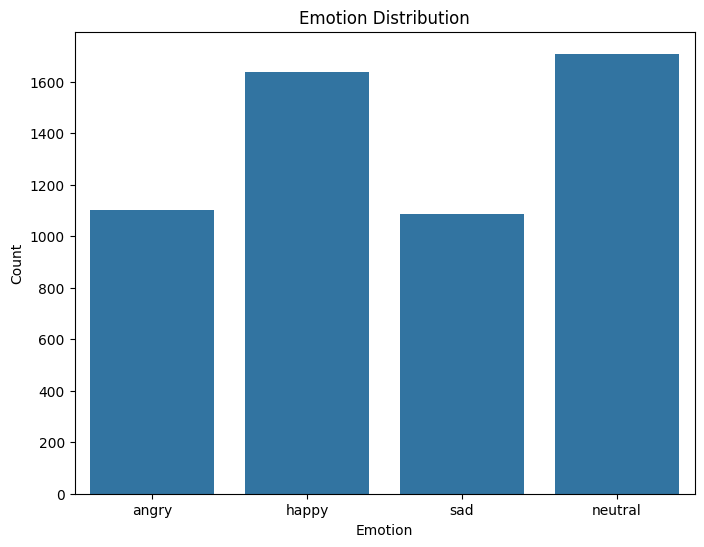

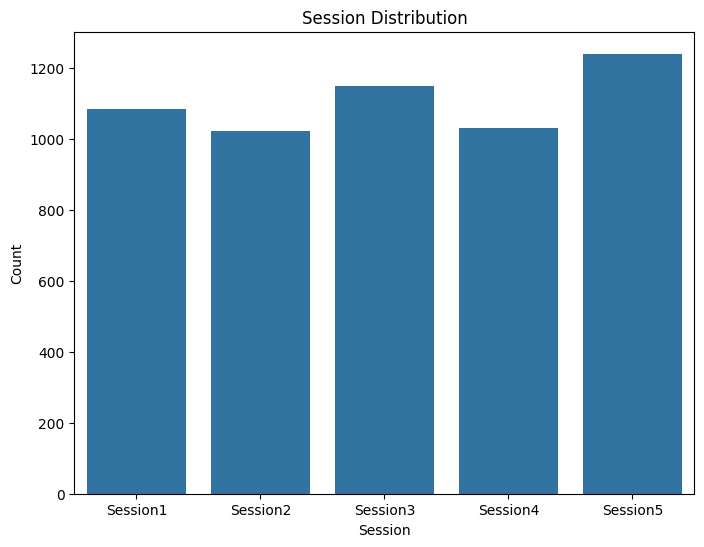

In [69]:
print("Analyzing metadata...")
try:
    data = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    print(f"Error: CSV file not found at {CSV_PATH}")
    raise

# Map emotions
data['mapped_emotion'] = data['emotion'].str.lower().map(LABEL_MAPPING)
data = data[data['mapped_emotion'].isin(EMOTION_CLASSES)]

# Compute summaries
summary['total_utterances'] = len(data)
summary['unique_utt_ids'] = data['utt_id'].nunique()
summary['emotion_counts'] = data['mapped_emotion'].value_counts().to_dict()
summary['session_counts'] = data['session'].value_counts().to_dict()
summary['missing_emotions'] = data['mapped_emotion'].isna().sum()

# Print summaries
print(f"Total utterances: {summary['total_utterances']}")
print(f"Unique utterance IDs: {summary['unique_utt_ids']}")
print(f"Emotion distribution: {summary['emotion_counts']}")
print(f"Session distribution: {summary['session_counts']}")
print(f"Missing emotions: {summary['missing_emotions']}")

# Plot emotion distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='mapped_emotion', order=EMOTION_CLASSES)
plt.title('Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_emotion_distribution.png'))
plt.show()

# Plot session distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='session', order=SESSIONS)
plt.title('Session Distribution')
plt.xlabel('Session')
plt.ylabel('Count')
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_session_distribution.png'))
plt.show()


Analyzing transcriptions...
Total transcriptions loaded: 10213
Missing transcriptions: 0
Vocabulary size (words with count >= 3): 1880
Average text length (tokens): 14.63
Text length range: 0 - 128


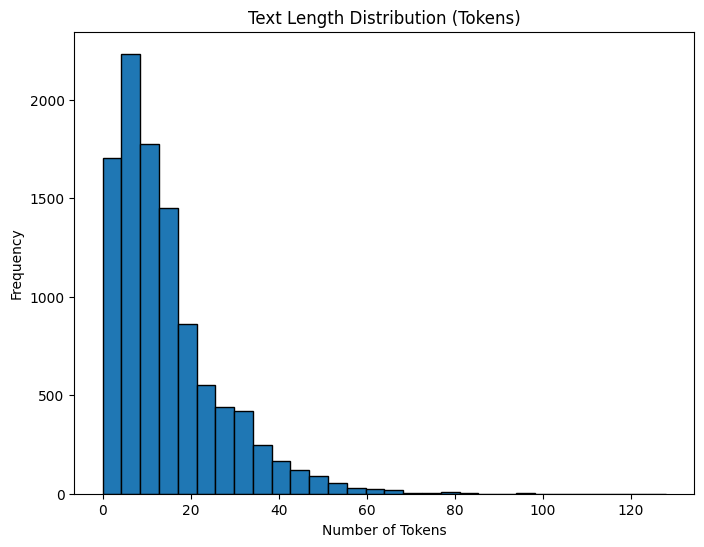

In [70]:
print("\nAnalyzing transcriptions...")
transcripts = {}
for session in SESSIONS:
    trans_dir = os.path.join(DATASET, session, 'dialog', 'transcriptions')
    if os.path.exists(trans_dir):
        for trans_file in os.listdir(trans_dir):
            if trans_file.endswith('.txt'):
                with open(os.path.join(trans_dir, trans_file), 'r') as f:
                    for line in f:
                        if line.strip():
                            utt_id = line.split('[')[0].strip()
                            text = line.split(':')[-1].strip()
                            transcripts[utt_id] = text

# Compute summaries
summary['total_transcriptions'] = len(transcripts)
summary['missing_transcriptions'] = len(data) - len(data[data['utt_id'].isin(transcripts.keys())])

# Text length and vocabulary
text_lengths = []
word_counts = Counter()
for text in transcripts.values():
    tokens = nltk.word_tokenize(text.lower())
    text_lengths.append(len(tokens))
    word_counts.update(tokens)

# Vocabulary (words with count >= 3)
vocab = [word for word, count in word_counts.items() if count >= 3]
summary['vocabulary_size'] = len(vocab)
summary['avg_text_length'] = np.mean(text_lengths) if text_lengths else 0.0

# Print summaries
print(f"Total transcriptions loaded: {summary['total_transcriptions']}")
print(f"Missing transcriptions: {summary['missing_transcriptions']}")
print(f"Vocabulary size (words with count >= 3): {summary['vocabulary_size']}")
print(f"Average text length (tokens): {summary['avg_text_length']:.2f}")
print(f"Text length range: {min(text_lengths) if text_lengths else 0} - {max(text_lengths) if text_lengths else 0}")

# Plot text length histogram
plt.figure(figsize=(8, 6))
plt.hist(text_lengths, bins=30, edgecolor='black')
plt.title('Text Length Distribution (Tokens)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_text_length_histogram.png'))
plt.show()


Analyzing MFCC features...


Processing MFCC files: 100%|██████████████████████████| 5531/5531 [00:03<00:00, 1433.31it/s]


Total valid MFCC files: 5531
Missing MFCC files: 0
Average MFCC sequence length (frames): 754.43
MFCC dimensions: 13
MFCC value range: -784.11 - 244.20


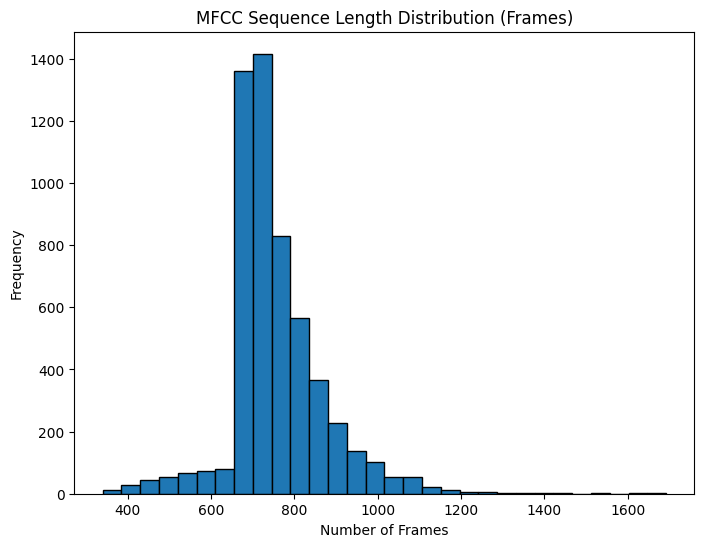

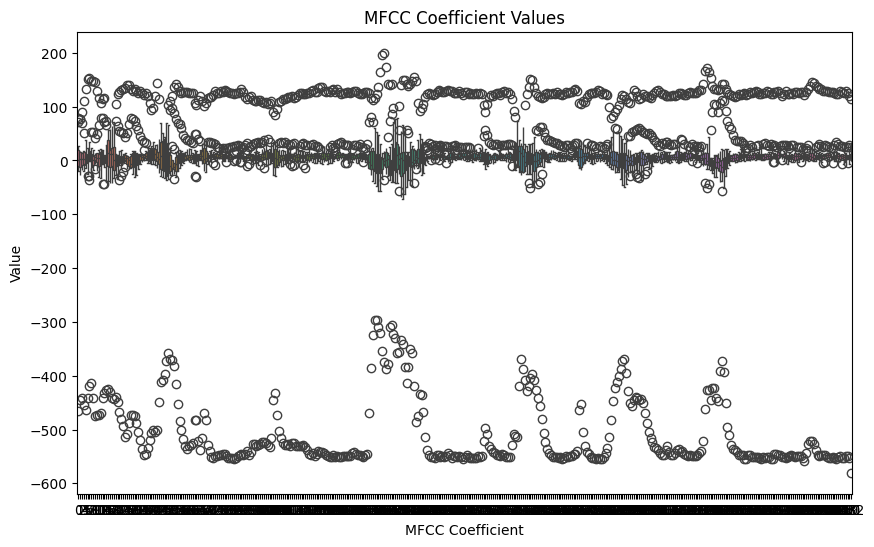

In [71]:
print("\nAnalyzing MFCC features...")
mfcc_seq_lengths = []
mfcc_values = []
valid_mfcc_files = 0

for _, row in tqdm(data.iterrows(), total=len(data), desc="Processing MFCC files"):
    mfcc_file = os.path.join(DATA_DIR, row['mfcc_path'])
    if os.path.exists(mfcc_file):
        try:
            mfcc = np.load(mfcc_file)
            valid_mfcc_files += 1
            mfcc_seq_lengths.append(mfcc.shape[0])
            mfcc_values.extend(mfcc.flatten())
        except Exception as e:
            print(f"Error loading MFCC {mfcc_file}: {e}")
    else:
        summary['missing_mfcc_files'] += 1

# Compute summaries
summary['total_mfcc_files'] = valid_mfcc_files
summary['avg_mfcc_seq_length'] = np.mean(mfcc_seq_lengths) if mfcc_seq_lengths else 0.0
summary['mfcc_dimensions'] = mfcc.shape[1] if valid_mfcc_files > 0 else 0

# Print summaries
print(f"Total valid MFCC files: {summary['total_mfcc_files']}")
print(f"Missing MFCC files: {summary['missing_mfcc_files']}")
print(f"Average MFCC sequence length (frames): {summary['avg_mfcc_seq_length']:.2f}")
print(f"MFCC dimensions: {summary['mfcc_dimensions']}")
print(f"MFCC value range: {min(mfcc_values) if mfcc_values else 0:.2f} - {max(mfcc_values) if mfcc_values else 0:.2f}")

# Plot MFCC sequence length histogram
plt.figure(figsize=(8, 6))
plt.hist(mfcc_seq_lengths, bins=30, edgecolor='black')
plt.title('MFCC Sequence Length Distribution (Frames)')
plt.xlabel('Number of Frames')
plt.ylabel('Frequency')
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_mfcc_seq_length_histogram.png'))
plt.show()

# Plot MFCC value boxplot
if valid_mfcc_files > 0:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=mfcc.T)
    plt.title('MFCC Coefficient Values')
    plt.xlabel('MFCC Coefficient')
    plt.ylabel('Value')
    plt.savefig(os.path.join(OUTPUT_DIR, 'eda_mfcc_boxplot.png'))
    plt.show()

In [72]:
summary_df = pd.DataFrame({
    'Metric': summary.keys(),
    'Value': [str(v) for v in summary.values()]
})
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'eda_summary.csv'), index=False)

print(f"EDA summary saved to {os.path.join(OUTPUT_DIR, 'eda_summary.csv')}")
print(f"Visualizations saved to {OUTPUT_DIR}")
print("\nSummary Metrics:")
print(summary_df)

EDA summary saved to plots/eda_summary.csv
Visualizations saved to plots

Summary Metrics:
                    Metric                                              Value
0         total_utterances                                               5531
1           unique_utt_ids                                               5531
2           emotion_counts  {'neutral': 1708, 'happy': 1636, 'angry': 1103...
3           session_counts  {'Session5': 1241, 'Session3': 1151, 'Session1...
4         missing_emotions                                                  0
5       missing_mfcc_files                                                  0
6     total_transcriptions                                              10213
7   missing_transcriptions                                                  0
8          vocabulary_size                                               1880
9          avg_text_length                                 14.630373053950846
10        total_mfcc_files                         